# Plot measurements.csv from OFF/runs
This notebook lists run folders, loads any `measurements.csv` files found inside, and lets you interactively plot selected columns.

In [1]:
# Imports & setup
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, SelectMultiple, Button, VBox, Output
from IPython.display import display

BASE_DIR = os.path.join(os.getcwd(), 'OFF', 'runs')
if not os.path.isdir(BASE_DIR):
    # Fallback: assume notebook already in OFF/runs
    BASE_DIR = os.getcwd()
print('Runs base:', BASE_DIR)

Runs base: c:\Users\daanvanderhoek\Nextcloud\PostDoc\Software\PyWakeDyn\OFF\runs


In [3]:
# Selected run directories
RUN_DIRS = [
    # os.path.join(BASE_DIR, 'off_run_20260216135343112309'),
    # # Add more runs here, e.g.:
    # os.path.join(BASE_DIR, 'off_run_20260216135154878136')
    os.path.join(BASE_DIR, 'off_run_20260227111343795525')  # Example placeholder
]

# Loader utilities
def find_measurement_files(run_dir):
    return sorted(glob.glob(os.path.join(run_dir, '**', 'measurements.csv'), recursive=True))


def load_measurements(run_dir):
    files = find_measurement_files(run_dir)
    if not files:
        print('No measurements.csv files found in', run_dir)
        return pd.DataFrame()
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df['__file__'] = os.path.relpath(f, BASE_DIR)
            dfs.append(df)
        except Exception as e:
            print(f'Failed to read {f}: {e}')
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


def load_measurements_multi(run_dirs):
    data = []
    for rd in run_dirs:
        if not isinstance(rd, str) or not os.path.isdir(rd):
            print('Not a valid run directory:', rd)
            continue
        df = load_measurements(rd)
        if df.empty:
            print('No measurements.csv files found in', rd)
            continue
        data.append((os.path.basename(rd), rd, df))
    return data

# Preview counts for selected runs
if RUN_DIRS:
    for rd in RUN_DIRS:
        try:
            cnt = len(find_measurement_files(rd))
            print('Found', cnt, 'measurements.csv file(s) in', os.path.basename(rd))
        except Exception:
            print('Unable to list files in', rd)

Found 1 measurements.csv file(s) in off_run_20260227111343795525


[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run_20260227111343795525] Column not found: Power_FLORIS
[off_run

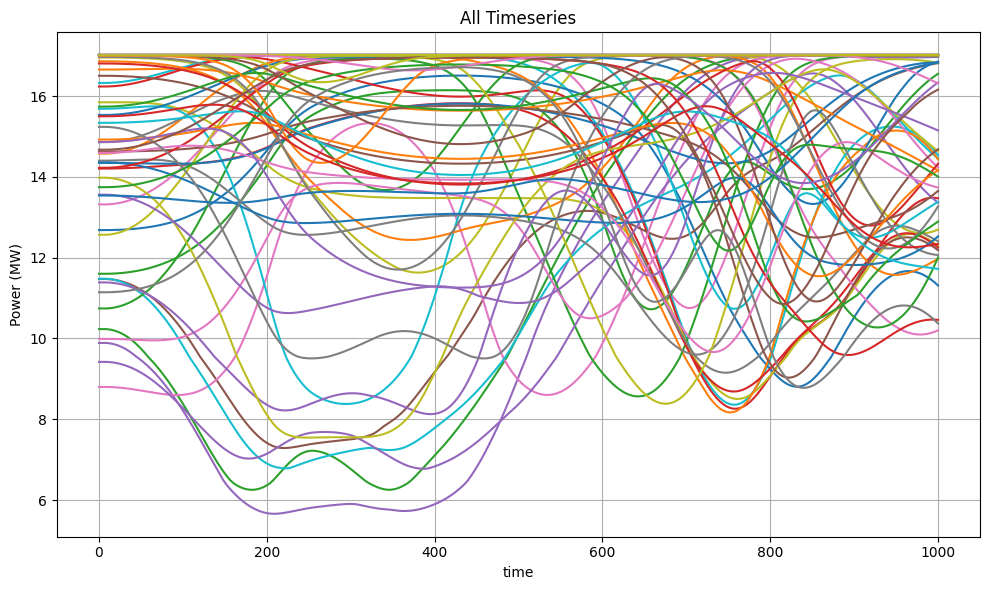

In [16]:
# Simple manual plot (multi-run, multi-turbine, no widgets)
# Configure selection
SELECTED_T_IDX = np.arange(0, 69)  # list of turbine indices or single int
SELECTED_COLUMNS = ['Power_FLORIS', 'Power_PyWake']  # columns to plot (check your measurements.csv for exact names)

# Resolve run directories
try:
    RUNS = RUN_DIRS
except NameError:
    RUNS = []

# Fallback to single run_dir if defined elsewhere
try:
    if not RUNS:
        if isinstance(run_dir, str):
            RUNS = [run_dir]
        elif isinstance(run_dir, (list, tuple)):
            RUNS = list(run_dir)
except NameError:
    pass

# Filter valid directories
RUNS = [rd for rd in RUNS if isinstance(rd, str) and os.path.isdir(rd)]
if not RUNS:
    print('Set RUN_DIRS (or run_dir) to one or more valid run folders under', BASE_DIR)
else:
    runs_data = load_measurements_multi(RUNS)
    if not runs_data:
        print('No measurements.csv files found in the selected runs')
    else:
        # Determine turbine indices to plot
        def any_has_tidx():
            return any('t_idx' in df.columns for _, _, df in runs_data)

        if any_has_tidx():
            if isinstance(SELECTED_T_IDX, (list, tuple, set, np.ndarray)):
                selected_tis = list(SELECTED_T_IDX)
            else:
                selected_tis = [SELECTED_T_IDX]
        else:
            selected_tis = [None]

        # Time axis detection
        time_cols = ['time', 't', 'timestamp', 'Time', 'T']
        def time_series_for(df_):
            for c in time_cols:
                if c in df_.columns:
                    return df_[c]
            return range(len(df_))

        # Create a single plot for all timeseries
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        y_total = np.zeros(251,)
        ylabel = None
        # Plot all turbines and all runs on the same axis
        for ti in selected_tis:
            for run_name, rd, df in runs_data:
                if ti is not None and 't_idx' in df.columns:
                    sub = df[df['t_idx'] == ti]
                    if sub.empty:
                        print(f'[{run_name}] No rows for t_idx={ti}')
                        continue
                else:
                    sub = df
                x = time_series_for(sub)
                for col in SELECTED_COLUMNS:
                    if col not in sub.columns:
                        print(f'[{run_name}] Column not found:', col)
                        continue
                    y = sub[col]
                    # Scale power-like columns to MW if applicable
                    if 'power' in col.lower():
                        y = y / 1e6
                        ylabel = 'Power (MW)'
                        y_total = np.sum([y_total, y], axis=0)
                    ax.plot(x, y)
        
        ax.set_title('All Timeseries')
        ax.set_xlabel('time' if 'time' in time_cols else 'index')
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.grid(True)

        plt.tight_layout()
        plt.show()
